In [63]:
#Reading data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('bmh')

from sklearn import svm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, f1_score, recall_score

 
df = pd.read_csv(r'C:\Users\jamal\OneDrive\Personal\AI ML Purdue\3rd project\HR_comma_sep.csv')
df_backup = df.copy()
df_test = df.copy()
df.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


### 1-	Perform data quality checks by checking for missing values, if any.

In [64]:
df.isna().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### 2-	Understand what factors contributed most to employee turnover at EDA.
##### 2.1-	Draw a heatmap of the correlation matrix between all numerical features or columns in the data

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0.5, 0, 'satisfaction_level'),
  Text(1.5, 0, 'last_evaluation'),
  Text(2.5, 0, 'number_project'),
  Text(3.5, 0, 'average_montly_hours'),
  Text(4.5, 0, 'time_spend_company'),
  Text(5.5, 0, 'Work_accident'),
  Text(6.5, 0, 'left'),
  Text(7.5, 0, 'promotion_last_5years')])

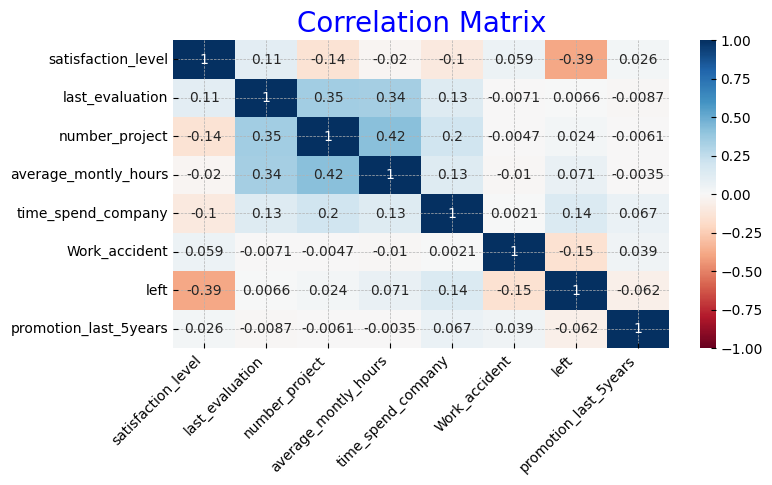

In [66]:
plt.figure(figsize=(8,4))
sns.heatmap(
    df_test.select_dtypes(include='number').corr(),
    annot=True,
    vmin=-1, vmax=1,
    cmap='RdBu',
    center=0
)
plt.title('Correlation Matrix', fontsize=20, color='blue')
plt.xticks(rotation=45, ha='right')



- Satisfaction level is inversely related to number of project and staying at the company
- Last evaluation is positively related to monthly hours


### 2.2 – Draw the distribution plot of:
- Employee Satisfaction (use column satisfaction_level)
- Employee Evaluation (use column last_evaluation)
- Employee Average Monthly Hours (use column average_montly_hours)

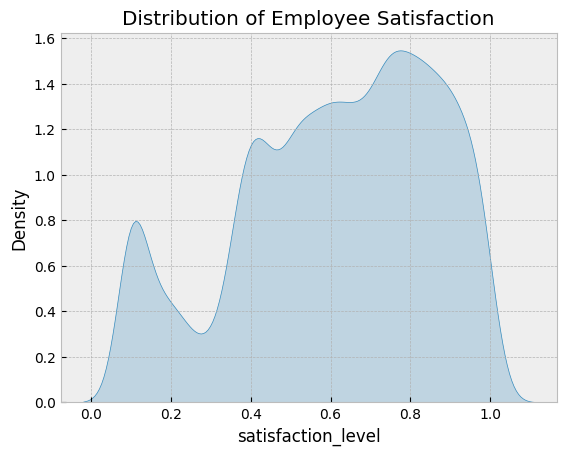

In [67]:
sns.kdeplot(df['satisfaction_level'], fill=True)
plt.title('Distribution of Employee Satisfaction')
plt.show()

Observation on Distribution of Employee Satisfaction

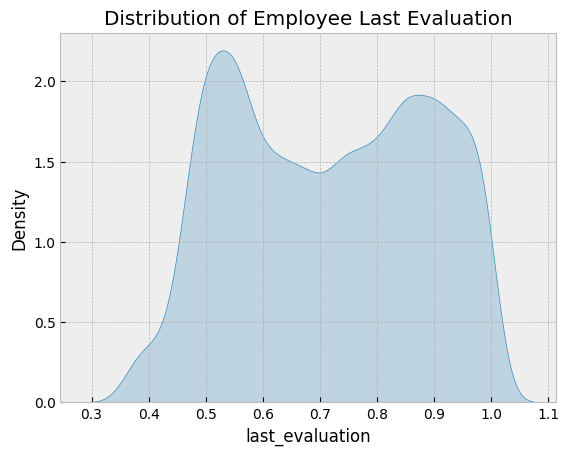

In [68]:
sns.kdeplot(df['last_evaluation'], fill=True)
plt.title('Distribution of Employee Last Evaluation')
plt.show()

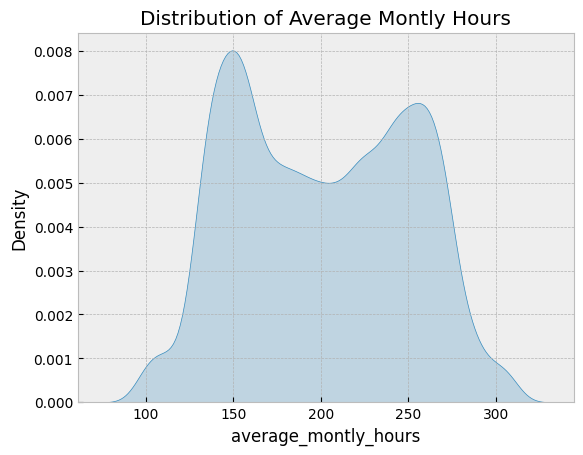

In [69]:
sns.kdeplot(df['average_montly_hours'], fill=True)
plt.title('Distribution of Average Montly Hours')
plt.show()

### 2.3.	Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot


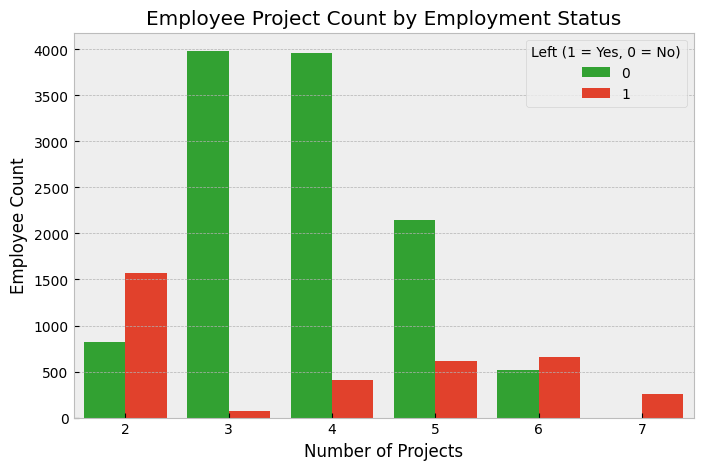

In [70]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='number_project',
    hue='left',
    palette=["#1fb41f", "#ff2a0e"]
)
plt.title('Employee Project Count by Employment Status')
plt.xlabel('Number of Projects')
plt.ylabel('Employee Count')
plt.legend(title='Left (1 = Yes, 0 = No)')
plt.show()

- Obersevations on Employee Project Count vs left
    - Employees with 3–4 projects are most likely to stay
    - People with very high (6 or more) or very low (2 or less) count of projects are not motivated to stay

<Axes: xlabel='number_project'>

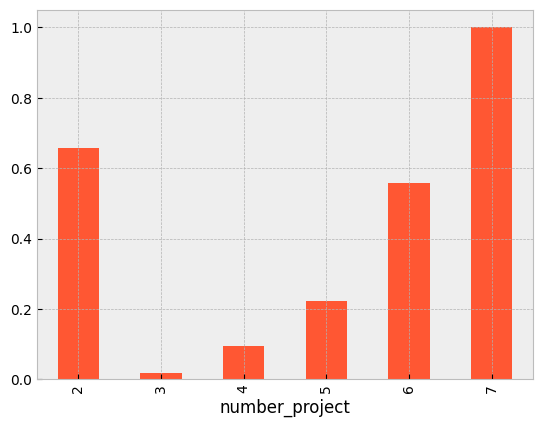

In [71]:
df.groupby('number_project')['left'].mean().plot(kind='bar', color='#ff5733')

### 3.	Perform clustering of employees who left based on their satisfaction and evaluation

In [72]:
df_left = df[df['left'] == 1]
X = df_left[['satisfaction_level', 'last_evaluation']]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [73]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df_left['cluster'] = kmeans.fit_predict(X_scaled)


C:\Users\jamal\AppData\Local\Temp\ipykernel_10272\1791642354.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_left['cluster'] = kmeans.fit_predict(X_scaled)


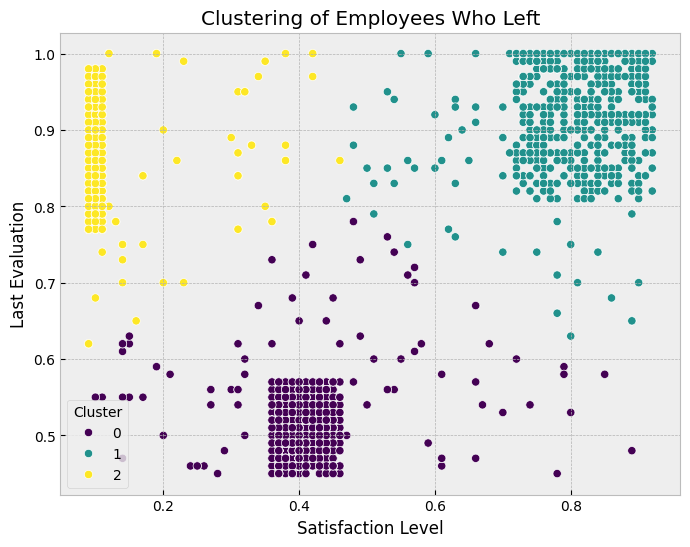

In [74]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_left,
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    palette='viridis'
)

plt.title("Clustering of Employees Who Left")
plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation")
plt.legend(title="Cluster")
plt.show()

In [75]:
df_left.groupby('cluster')[['satisfaction_level', 'last_evaluation']].mean()


,satisfaction_level,last_evaluation
cluster,,
0,0.412304,0.517265
1,0.808031,0.916415
2,0.111321,0.870884


- Cluster 0 → Low satisfaction, average evaluation
- Cluster 1 → High evaluation, low satisfaction (overworked high performers)
- Cluster 2 → Moderate satisfaction & evaluation
- Some leave despite high performance
- Some leave due to burnout
- Some leave due to general disengagement

In [76]:
df_copy = df.copy()

### 4.	Handle the left Class Imbalance using the SMOTE technique


Text(0.5, 1.0, 'Left vs Stayed Proportion')

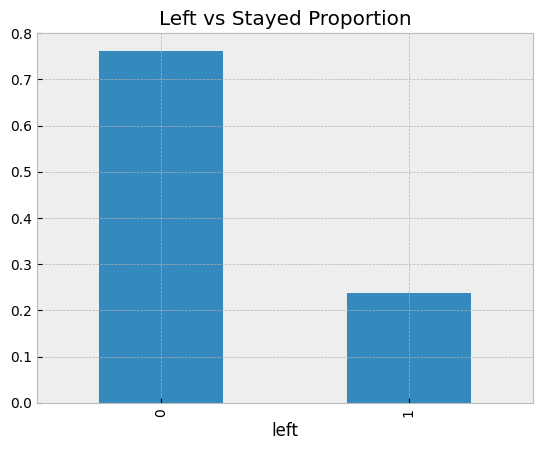

In [77]:
# checking the proportion of employees who left vs stayed
df['left'].value_counts(normalize=True).plot(kind='bar')
plt.title('Left vs Stayed Proportion')

In [78]:
#Pre-process the data by converting categorical columns to numerical columns 
df.sample(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
14875,0.36,0.49,2,147,3,0,1,0,marketing,low
3096,0.71,0.66,3,238,2,0,0,0,technical,low
6329,0.95,0.37,6,233,5,0,0,0,RandD,medium
9099,0.69,0.75,3,204,3,0,0,0,sales,low
4841,0.68,0.83,3,133,3,0,0,0,hr,low
319,0.40,0.46,2,130,3,0,1,0,sales,low
12356,0.41,0.55,2,154,3,0,1,0,support,low
1668,0.82,0.94,5,232,5,1,1,0,IT,medium
10199,0.61,0.56,2,160,3,0,0,0,support,medium
5443,0.62,0.74,4,173,2,0,0,0,sales,medium


In [79]:
# applying get_dummies to categorical columns "Department" & "salary"
df = pd.get_dummies(df, columns=['Department', 'salary'], dtype=int)

In [80]:
df.sample(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_IT,Department_RandD,...,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_high,salary_low,salary_medium
11900,0.83,0.57,2,222,2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
14290,0.39,0.56,2,142,3,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
12476,0.11,0.87,5,271,4,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
986,0.36,0.50,2,158,3,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
6332,0.98,0.53,6,253,4,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
7580,0.98,0.99,3,235,3,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
11975,0.59,0.77,3,272,8,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
10631,0.60,0.62,5,165,2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1142,0.88,1.00,5,226,6,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
7149,0.38,0.47,3,189,5,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [81]:
X = df.drop('left', axis=1)
y = df['left']


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

In [83]:
#Applying SMOTE to balance the dataset
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=123)
X_train_resample, y_train_resample = sm.fit_resample(X_train, y_train)


In [84]:
y.shape, y_train_resample.shape  #balaned dataset after SMOTE 

((14999,), (18284,))

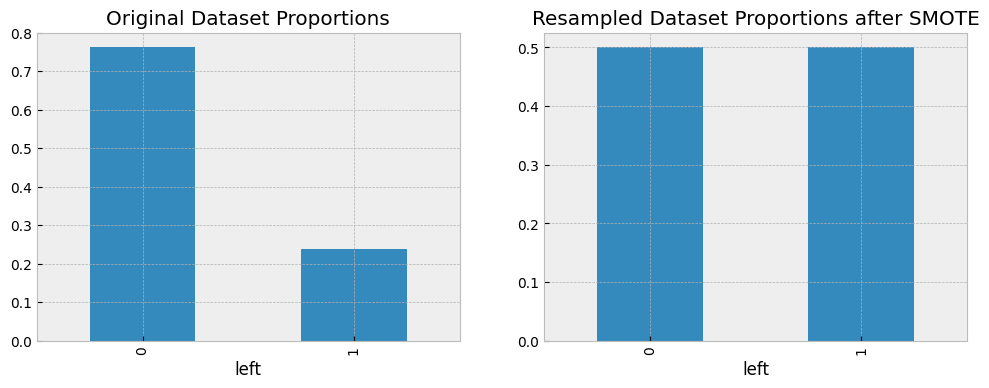

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y.value_counts(normalize=True).plot(kind='bar', ax=axes[0], title='Original Dataset Proportions')
y_train_resample.value_counts(normalize=True).plot(kind='bar', ax=axes[1], title='Resampled Dataset Proportions after SMOTE')
plt.show()  

### 5.	Perform 5-fold cross-validation model training and evaluate performance
#### Logistic Regression

## Important note 

Important SMOTE best practice (exam / interview note)

What you did works, but the best practice is:

Apply SMOTE only on the training set, not before splitting.

Why?
Because SMOTE can leak information from test data into training.

Gold-standard version (recommended)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


Then train on:

rf_model.fit(X_train_res, y_train_res)


In [86]:
#Train a logistic regression model, apply a 5-fold CV, and plot the classification report.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score



In [87]:
# model
log_reg = LogisticRegression(random_state=123, solver='liblinear')

# train
log_reg.fit(X_train_resample, y_train_resample)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",123
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [88]:

#CV fold
cv_scores = cross_val_score(
    log_reg, X_train_resample, y_train_resample, cv=5
)

# predict
y_pred_lr = log_reg.predict(X_train_resample)



print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

CV scores: [0.74159147 0.78671042 0.83237626 0.84194695 0.83780088]
Mean CV accuracy: 0.808085195563318


In [89]:
y_pred_lr = log_reg.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.80      0.85      2286
           1       0.53      0.73      0.62       714

    accuracy                           0.78      3000
   macro avg       0.72      0.77      0.73      3000
weighted avg       0.82      0.78      0.79      3000



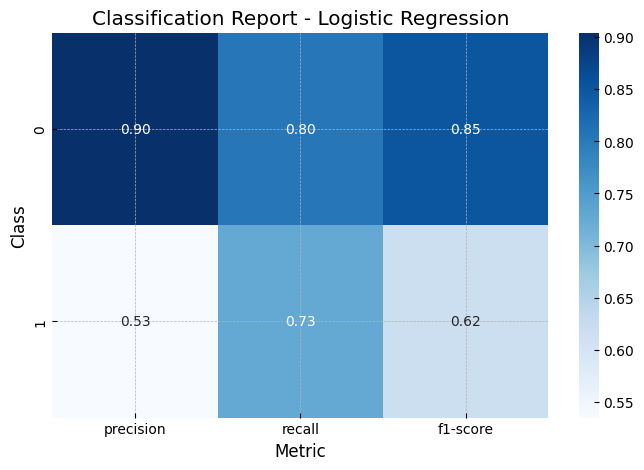

In [90]:
report_lg = classification_report(
    y_test,
    y_pred_lr,
    output_dict=True
)

df_report_lg = pd.DataFrame(report_lg).transpose()

plt.figure(figsize=(8, 5))

sns.heatmap(
    df_report_lg.iloc[:-3, :-1],  # drop support & accuracy row
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Classification Report - Logistic Regression")
plt.ylabel("Class")
plt.xlabel("Metric")
plt.show()

#### Random Forest Classifier model

In [91]:
from sklearn.ensemble import RandomForestClassifier



rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=123,
    n_jobs=-1
)

cv_scores_rf = cross_val_score(rf_model, X_train_resample, y_train_resample, cv=5)


rf_model.fit(X_train_resample, y_train_resample)

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.97      0.98      0.97       714

    accuracy                           0.99      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



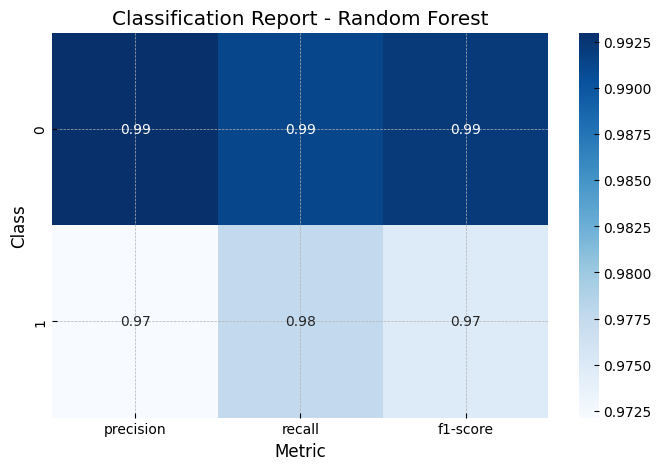

In [92]:
report_rf = classification_report(
    y_test,
    y_pred_rf,
    output_dict=True
)

df_report = pd.DataFrame(report_rf).transpose()

plt.figure(figsize=(8, 5))

sns.heatmap(
    df_report.iloc[:-3, :-1],  # drop support & accuracy row
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Classification Report - Random Forest")
plt.ylabel("Class")
plt.xlabel("Metric")
plt.show()

#### Gradient Boosting Classifier

In [93]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict
#create the GBC mode
gbc = GradientBoostingClassifier(random_state=123)

#perform 5-fold cross-validation
y_pred_cv_gbc = cross_val_score(
    gbc,
    X_train_resample,
    y_train_resample,
    cv=5,
    scoring='f1'
)

print("CV F1 scores:", y_pred_cv_gbc)
print("Mean F1:", y_pred_cv_gbc.mean())
gbc.fit(X_train_resample, y_train_resample)

CV F1 scores: [0.95797384 0.95962128 0.96428571 0.96002221 0.95809048]
Mean F1: 0.9599987035507314


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [94]:
y_pred_gbc = gbc.predict(X_test)
print(classification_report(y_test, y_pred_gbc))    


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2286
           1       0.92      0.94      0.93       714

    accuracy                           0.97      3000
   macro avg       0.95      0.96      0.95      3000
weighted avg       0.97      0.97      0.97      3000



#### ROC/AUC for each model and plot the ROC curve.

Logistic Regression AUC: 0.82
Random Forest AUC: 0.99
Gradient Boosting AUC: 0.99


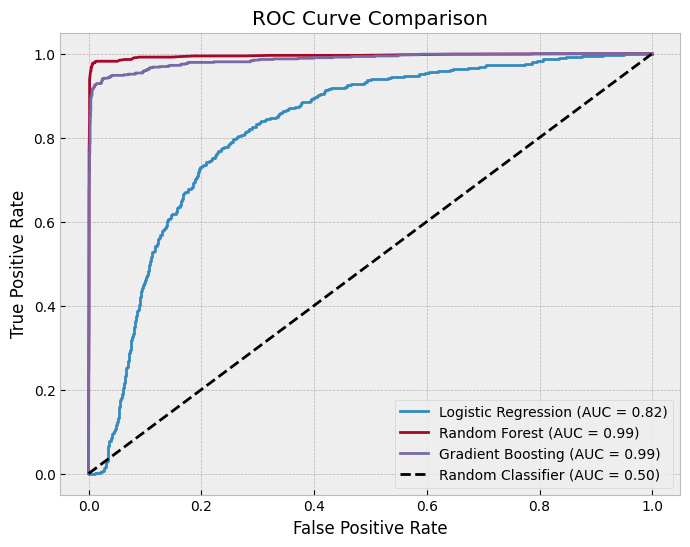

In [95]:
from sklearn.metrics import roc_curve, auc

# Getting predicted probabilities for the positive class
y_pred_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_proba_gbc = gbc.predict_proba(X_test)[:, 1]

# Calculating True Positive Rate (Sensitivity) & False Positive Rate, and thresholds for each model
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_proba_log_reg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_gb, tpr_gbc, _ = roc_curve(y_test, y_pred_proba_gbc)

# Calculate the Areas under the ROC curve for each model
log_reg_auc = auc(fpr_log_reg, tpr_log_reg)
print(f'Logistic Regression AUC: {log_reg_auc:.2f}')
rf_auc = auc(fpr_rf, tpr_rf)
print(f'Random Forest AUC: {rf_auc:.2f}')
gb_auc = auc(fpr_gb, tpr_gbc)
print(f'Gradient Boosting AUC: {gb_auc:.2f}')

# Plot the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {log_reg_auc:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(fpr_gb, tpr_gbc, label=f'Gradient Boosting (AUC = {gb_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Confusion Matrices

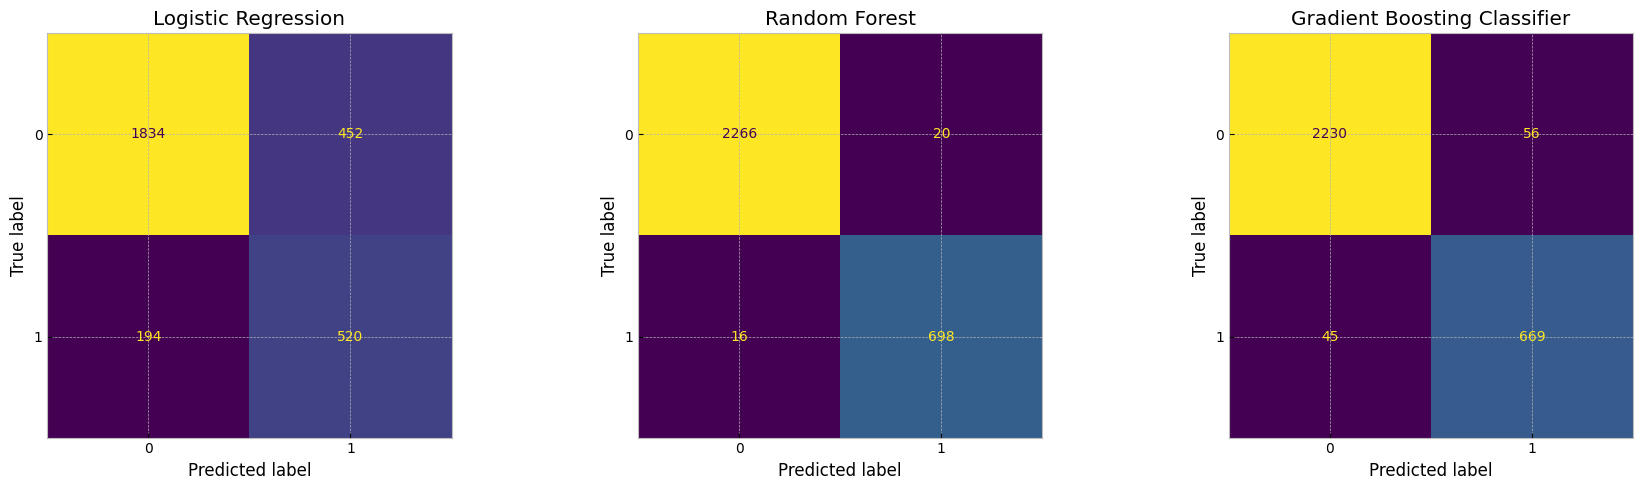

In [96]:
from sklearn.metrics import ConfusionMatrixDisplay

models = [log_reg, rf_model, gbc]

names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting Classifier']

# 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# loop over axes + models
for ax, model, name in zip(axes, models, names):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        colorbar=False
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


- In our HR dataset `Recall` means how many employees who left the company are idetified correctly
 - while `Precision` Of all employees we predicted will leave, how many actually did
 - Looks like Recall is more important metrics for this application, as False negatives are worse than false positives, and the cost of leaving company is expensive 
 - From above confusion matricies, Random Forest stands out as the best model for this application

#### Predicting the probability of employee turnover in the test data using Random Forest model

In [99]:
# Predict probabilities
rf_test_proba = rf_model.predict_proba(X_test)

# Extract probability of employee leaving (class = 1)
rf_turnover_prob = rf_test_proba[:, 1]


rf_proba_df = pd.DataFrame({
    "Turnover_Probability": rf_turnover_prob
})

rf_pred_class = rf_model.predict(X_test)

rf_proba_df["Predicted_Class"] = rf_pred_class
rf_proba_df["Actual_Class"] = y_test.values


def assign_risk_zone(prob_percent):
    if prob_percent < 20:
        return "Safe Zone (Green)"
    elif prob_percent < 60:
        return "Low-Risk Zone (Yellow)"
    elif prob_percent < 90:
        return "Medium-Risk Zone (Orange)"
    else:
        return "High-Risk Zone (Red)"
    

rf_proba_df["Risk_Zone"] = (
    rf_proba_df["Turnover_Probability"] * 100
).apply(assign_risk_zone)

rf_proba_df.head(10)


,Turnover_Probability,Predicted_Class,Actual_Class,Risk_Zone
0,0.00,0,0,Safe Zone (Green)
1,0.71,1,0,Medium-Risk Zone (Orange)
2,0.13,0,0,Safe Zone (Green)
3,0.01,0,0,Safe Zone (Green)
4,0.04,0,0,Safe Zone (Green)
5,0.00,0,0,Safe Zone (Green)
6,0.00,0,0,Safe Zone (Green)
7,0.00,0,0,Safe Zone (Green)
8,0.03,0,0,Safe Zone (Green)
9,0.00,0,0,Safe Zone (Green)


#### Suggested Retention Strategies
The Random Forest model was used to estimate the probability of employee turnover on the test dataset, and employees were categorized into risk zones based on predicted probabilities.

#### 1. Safe Zone (Green: <20%)
    - Profile: These are your most stable and satisfied employees.
    - Strategy: Recognition and Development. * Focus on long-term career pathing and leadership development to keep them engaged.
    - Use these employees as "culture champions" or mentors for new hires.
    - Maintain regular 1-on-1s to ensure their needs continue to be met before they slip into other categories.

#### 2. Low-Risk Zone (Yellow: 20% - 59%)
    - Profile: These employees are generally stable but might be experiencing minor "nudges" toward leaving (e.g., slight stagnation or workload fluctuations).
    - Strategy: Engagement and Feedback.
    - Conduct "stay interviews" to understand what they value most about the company.
    - Offer professional development opportunities or small shifts in project scope to renew interest.
    - Monitor their workload; the data suggests factors like average_monthly_hours and number_project are key drivers of turnover.

#### 3. Medium-Risk Zone (Orange: 60% - 89%)
    - Profile: These employees are likely actively considering other opportunities or are significantly dissatisfied.
    - Strategy: Intervention and Compensation Review.
    - Immediate intervention by direct managers is required to address specific pain points (e.g., lack of promotion or poor work-life balance).
    - Review their salary against the market; the dataset shows a correlation between salary levels and the decision to leave.
    - Check for a history of promotions; if they haven't been promoted in the last 5 years, they are at much higher risk.

#### 4. High-Risk Zone (Red: > 90%)
    - Profile: These employees have a very high likelihood of leaving soon.
    - Strategy: Critical Mitigation or Succession Planning.
    - If the employee is a high performer, explore immediate "stop-gap" measures such as a retention bonus, a role change, or a significant promotion.
    - Simultaneously, begin succession planning and knowledge transfer tasks to minimize business disruption if they do depart.
    - Analyze if their high risk is due to burnout (e.g., very high average_monthly_hours) and offer immediate relief if possible.